# 14. 최종모형 v2 강건성 검증 (전체)

**v2 본모형** (`13_최종모형_v2`, `../최종모형_v2.md`):
셀 × 노선, 오전 07~09시, Poisson QMLE, offset log(2024), 노선 FE, 셀 군집 SE.
X = **log(보행시간)**, **IC 도로거리**.
본 결과: 보행시간 2배당 +27.1% (p<0.001), IC 1km당 −11.6% (p<0.001).

이 노트북 하나에 v2 변수 기준의 강건성 검증을 모두 모았다.

| # | 검증 | 질문 |
|---|---|---|
| 1 | 역 권역·셀·노선 하나씩 빼기 | 특정 역/셀/노선이 결과를 만들었나 |
| 2 | 고정효과 구조 | FE 없음 / 노선 / 역 / 노선+역에서 유지되나 |
| 3 | 공간자기상관 | 잔차 Moran's I, 읍면동 군집, Conley SE |
| 4 | 0 포함 패널 | 2024=0 쌍을 빼서 생긴 선택편향은 없나 |
| 5 | 시간대 | 오전 외 시간대에서도 같은가 |
| 6 | 함수형·경계 | log 대신 선형·구간·단일 경계 10~60분이면 |
| 7 | 추정법·가중치 | 음이항, WLS, 가중치 없는 OLS, 승차 규모별 |
| 8 | offset 가정 | θ 자유, 독립 규모 통제 (13번 재확인) |
| — | **종합표** | 맨 아래 |

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # 정리본 최상위의 config.py

from config import *
setup_notebook()

import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import norm

data = load_model_data()
data["log_walk"] = np.log(data["walk_min"])
X_V2 = ["log_walk", "ic_access"]
trips = load_trips().dropna(subset=["셀 ID"])


def build_pairs(hours, keep_zero=False):
    frame = (trips[trips["시"].between(*hours)]
             .pivot_table(index=["셀 ID", "노선"], columns="연도", values="승차인원", aggfunc="sum", fill_value=0)
             .reset_index().rename(columns={2024: "y2024", 2025: "y2025"}))
    frame["셀 ID"] = frame["셀 ID"].astype(int)
    frame = frame.merge(data[["셀 ID", "walk_min", "log_walk", "walk_20", "walk_20_60", "ic_access", "nearest_station"]], on="셀 ID")
    return frame.reset_index(drop=True) if keep_zero else frame[frame.y2024 > 0].reset_index(drop=True)


morning = build_pairs(MORNING_HOURS)


def design(frame, x_cols, route_fe=True, station_fe=False):
    parts = [frame[x_cols]]
    if route_fe:
        parts.append(pd.get_dummies(frame.노선, prefix="노선", drop_first=True, dtype=float))
    if station_fe:
        parts.append(pd.get_dummies(frame.nearest_station, prefix="역", drop_first=True, dtype=float))
    return pd.concat(parts, axis=1)


def fit(frame, x_cols=X_V2, route_fe=True, station_fe=False, cluster="셀 ID", offset=True):
    frame = frame.reset_index(drop=True)
    model = sm.GLM(frame.y2025, sm.add_constant(design(frame, x_cols, route_fe, station_fe)),
                   family=sm.families.Poisson(), offset=np.log(frame.y2024) if offset else None)
    return model.fit(cov_type="cluster", cov_kwds={"groups": pd.factorize(frame[cluster])[0]})


def walk2x(b):
    return (2 ** b - 1) * 100


def ic1km(b):
    return (np.exp(b) - 1) * 100


def summary(result, label, pvals=None):
    """종합표 한 행: 보행시간 2배당, IC 1km당 효과와 p."""
    p = result.pvalues if pvals is None else pvals
    return {"검증": label, "보행시간 2배당(%)": walk2x(result.params["log_walk"]), "보행 p": p["log_walk"],
            "IC 1km당(%)": ic1km(result.params["ic_access"]), "IC p": p["ic_access"]}


main = fit(morning)
ROWS = [summary(main, "★ v2 본모형")]
pd.DataFrame(ROWS).round(4)

,검증,보행시간 2배당(%),보행 p,IC 1km당(%),IC p
0,★ v2 본모형,27.1165,0.0,-11.6237,0.0007


## 1. 하나씩 빼기 (역 권역 · 셀 · 노선)

In [2]:
rows = []
for station in ["운정중앙", "킨텍스", "대곡"]:
    f = morning[morning.nearest_station != station]
    r = fit(f)
    rows.append({**summary(r, f"역 권역 제외: {station}"), "남은 셀": f["셀 ID"].nunique(), "남은 보행20분이내 셀": f.loc[f.walk_20 == 1, "셀 ID"].nunique()})
station_loo = pd.DataFrame(rows)
ROWS += rows
station_loo.round(4)

,검증,보행시간 2배당(%),보행 p,IC 1km당(%),IC p,남은 셀,남은 보행20분이내 셀
0,역 권역 제외: 운정중앙,34.9881,0.0003,-11.0967,0.0393,62,5
1,역 권역 제외: 킨텍스,11.7053,0.1221,-11.8941,0.0010,92,7
2,역 권역 제외: 대곡,20.8753,0.0002,-7.6623,0.0340,82,10


In [3]:
def loo(column):
    out = []
    for value in morning[column].unique():
        r = fit(morning[morning[column] != value])
        out.append({column: value, "보행 효과(%)": walk2x(r.params["log_walk"]), "보행 p": r.pvalues["log_walk"],
                    "IC 효과(%)": ic1km(r.params["ic_access"]), "IC p": r.pvalues["ic_access"]})
    return pd.DataFrame(out)


cell_loo, route_loo = loo("셀 ID"), loo("노선")
rows = []
for name, table in [("셀 하나씩 빼기 (118회)", cell_loo), ("노선 하나씩 빼기 (24회)", route_loo)]:
    rows.append({"검증": name,
                 "보행 효과 범위(%)": f"{table['보행 효과(%)'].min():.1f} ~ {table['보행 효과(%)'].max():.1f}",
                 "보행 p 최대": table["보행 p"].max(), "보행 p>0.05 횟수": int((table["보행 p"] > 0.05).sum()),
                 "IC 효과 범위(%)": f"{table['IC 효과(%)'].min():.1f} ~ {table['IC 효과(%)'].max():.1f}",
                 "IC p 최대": table["IC p"].max(), "IC p>0.05 횟수": int((table["IC p"] > 0.05).sum())})
    worst_walk = table.loc[table["보행 p"].idxmax()]
    worst_ic = table.loc[table["IC p"].idxmax()]
    ROWS.append({"검증": f"{name} — 보행 p가 가장 큰 경우 ({table.columns[0]} {worst_walk.iloc[0]})",
                 "보행시간 2배당(%)": worst_walk["보행 효과(%)"], "보행 p": worst_walk["보행 p"],
                 "IC 1km당(%)": worst_walk["IC 효과(%)"], "IC p": worst_walk["IC p"]})
    ROWS.append({"검증": f"{name} — IC p가 가장 큰 경우 ({table.columns[0]} {worst_ic.iloc[0]})",
                 "보행시간 2배당(%)": worst_ic["보행 효과(%)"], "보행 p": worst_ic["보행 p"],
                 "IC 1km당(%)": worst_ic["IC 효과(%)"], "IC p": worst_ic["IC p"]})
display(pd.DataFrame(rows).round(4))
print("노선 빼기에서 p가 큰 순:")
route_loo.sort_values("보행 p", ascending=False).head(5).round(4)

,검증,보행 효과 범위(%),보행 p 최대,보행 p>0.05 횟수,IC 효과 범위(%),IC p 최대,IC p>0.05 횟수
0,셀 하나씩 빼기 (118회),22.8 ~ 30.1,0.0041,0,-12.8 ~ -9.8,0.0028,0
1,노선 하나씩 빼기 (24회),18.6 ~ 29.1,0.0105,0,-12.7 ~ -10.3,0.0030,0


노선 빼기에서 p가 큰 순:


,노선,보행 효과(%),보행 p,IC 효과(%),IC p
17,M7731,25.2164,0.0105,-11.9903,0.0012
8,1000,18.5669,0.0012,-11.4384,0.0003
1,3100,25.1761,0.0002,-10.8186,0.0030
9,2200,28.4074,0.0000,-12.0398,0.0014
16,G7625,26.0234,0.0000,-11.3544,0.0010


**해석**
- 셀 118개, 노선 24개를 하나씩 빼도 두 변수 모두 **매번 유의**하다. 특정 셀이나 노선 하나가 결과를 만든 게 아니다.
- **역 권역 단위로는 여전히 킨텍스가 약한 고리다.**
  - 킨텍스 권역을 빼면 보행시간 효과가 +11.7%(p=0.12)로 유의하지 않다.
  - 운정중앙이나 대곡을 빼면 유지된다(+35%, +21%, 둘 다 p<0.001).
  - IC 효과는 어느 권역을 빼도 유의하다.
- → 보행시간 효과의 상당 부분이 킨텍스역 주변 셀에서 식별된다. 본문 한계에 명시한다.

## 2. 고정효과 구조

| 사양 | 답하는 질문 |
|---|---|
| FE 없음 | 전체적으로 GTX에 가까운 셀이 더 줄었나 (노선 간 + 노선 내 + 권역 간 차이 모두 포함) |
| 노선 FE (본) | 같은 노선 안에서 가까운 정류장이 더 줄었나 |
| 역 FE | 같은 역 권역 안에서 가까운 셀이 더 줄었나 |
| 노선 + 역 FE | 같은 노선·같은 권역 안의 거리 기울기 (가장 엄격) |

In [4]:
rows = []
for label, rfe, sfe in [("FE 없음", False, False), ("노선 FE (본)", True, False), ("역 FE", False, True), ("노선 FE + 역 FE", True, True)]:
    rows.append(summary(fit(morning, route_fe=rfe, station_fe=sfe), f"고정효과: {label}"))
ROWS += [r for r in rows if "본" not in r["검증"]]
pd.DataFrame(rows).round(4)

,검증,보행시간 2배당(%),보행 p,IC 1km당(%),IC p
0,고정효과: FE 없음,11.4633,0.1024,-10.0197,0.0034
1,고정효과: 노선 FE (본),27.1165,0.0000,-11.6237,0.0007
2,고정효과: 역 FE,5.8890,0.3019,-5.9288,0.0491
3,고정효과: 노선 FE + 역 FE,19.4446,0.0007,-9.0681,0.0022


**해석**
- **노선 FE가 있어야 보행시간 효과가 유의하다.**
  - FE 없음: +11.5%, p=0.10
  - 역 FE만: +5.9%, p=0.30
  - 노선 FE: +27.1%, p<0.001
  - 노선 + 역 FE: +19.4%, p<0.001
- 의미: 보행시간의 '연속적인 거리 기울기'는 **같은 노선 안에서** 뚜렷하다. 노선을 통제하지 않으면 노선 구성 차이(예: 킨텍스 권역의 M7731·M7412 증가)가 기울기를 가린다.
- **노선 + 역 FE(가장 엄격한 사양)에서도 유의**하다. "같은 노선, 같은 역 권역 안에서도 가까울수록 더 줄었다"는 뜻이라 v2 결론의 가장 강한 근거다.
- 역 FE만 넣었을 때 사라지는 건, 노선 구성 차이를 통제하지 않은 채 권역 간 차이만 제거했기 때문이다. 이 사양은 연구 질문(노선 내 전환)에 맞지 않는다.
- IC 효과는 모든 사양에서 유의하다.
- → 논문에서는 "효과는 노선 내 비교에서 식별된다"고 명시하고, 노선 + 역 FE 결과를 강건성으로 제시한다.

## 3. 공간자기상관

In [5]:
centers = stable_centers().set_index("셀 ID")
cells = morning.assign(mu=main.mu).groupby("셀 ID")[["y2025", "mu"]].sum()
cells["resid"] = (cells.y2025 - cells.mu) / np.sqrt(cells.mu)
xy = np.c_[centers.loc[cells.index].geometry.x, centers.loc[cells.index].geometry.y]
D = np.sqrt(((xy[:, None] - xy[None]) ** 2).sum(-1))


def morans_i(values, W):
    z = values - values.mean()
    return len(z) / W.sum() * (z @ W @ z) / (z @ z)


rng = np.random.default_rng(0)
rows = []
for label, W in [("1km 이내", ((D > 0) & (D <= 1000)).astype(float)), ("2km 이내", ((D > 0) & (D <= 2000)).astype(float)),
                 ("최근접 5개", (D <= np.sort(D, axis=1)[:, [5]]).astype(float) - np.eye(len(D)))]:
    W = W / np.where(W.sum(1, keepdims=True) > 0, W.sum(1, keepdims=True), 1)
    observed = morans_i(cells.resid.values, W)
    simulated = np.array([morans_i(rng.permutation(cells.resid.values), W) for _ in range(999)])
    rows.append({"가중치": label, "Moran's I": observed, "순열 p": (np.sum(simulated >= observed) + 1) / 1000})
pd.DataFrame(rows).round(3)

,가중치,Moran's I,순열 p
0,1km 이내,0.095,0.125
1,2km 이내,0.035,0.210
2,최근접 5개,0.030,0.229


In [6]:
def conley_pvalues(frame, result, cutoff_m):
    Xv = sm.add_constant(design(frame, X_V2)).values
    mu = np.asarray(result.mu)
    score = Xv * (frame.y2025.values - mu)[:, None]
    bread = np.linalg.pinv(Xv.T @ (Xv * mu[:, None]))
    cxy = np.c_[centers.loc[frame["셀 ID"]].geometry.x, centers.loc[frame["셀 ID"]].geometry.y]
    dist = np.sqrt(((cxy[:, None] - cxy[None]) ** 2).sum(-1))
    se = np.sqrt(np.diag(bread @ (score.T @ np.clip(1 - dist / cutoff_m, 0, None) @ score) @ bread))
    names = ["const"] + list(design(frame, X_V2).columns)
    return pd.Series(2 * norm.sf(np.abs(result.params.values / se)), index=names)


def fix_korean(text):
    try:
        return str(text).encode("latin1").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return str(text)


emd = read_csv(IC_PATH)[["셀 ID", "emd_nm_k"]].assign(읍면동=lambda d: d.emd_nm_k.map(fix_korean))[["셀 ID", "읍면동"]]
rows = [summary(fit(morning.merge(emd, on="셀 ID"), cluster="읍면동"), "표준오차: 읍면동 군집")]
for km in (1, 2, 5):
    rows.append(summary(main, f"표준오차: Conley {km}km", pvals=conley_pvalues(morning, main, km * 1000)))
ROWS += rows
pd.DataFrame(rows).round(4)

,검증,보행시간 2배당(%),보행 p,IC 1km당(%),IC p
0,표준오차: 읍면동 군집,27.1165,0.0014,-11.6237,0.0108
1,표준오차: Conley 1km,27.1165,0.0000,-11.6237,0.0010
2,표준오차: Conley 2km,27.1165,0.0001,-11.6237,0.0019
3,표준오차: Conley 5km,27.1165,0.0000,-11.6237,0.0038


**해석**
- 본모형 잔차에 공간자기상관이 없다 (Moran's I 0.03~0.10, 모두 p>0.12).
- 읍면동 군집, Conley 1·2·5km 표준오차에서도 두 변수 모두 p<0.05다. → **공간 문제 없음.**

## 4. 2024=0 쌍을 포함한 쌍 고정효과 Poisson 패널
연도별 2행으로 펼쳐 `log E[y_irt] = α_ir + post_t · (Xβ + γ_r)`를 추정한다. 2024=0, 2025>0인 쌍도 정보에 들어간다.

In [7]:
zero = build_pairs(MORNING_HOURS, keep_zero=True)
long = zero[(zero.y2024 + zero.y2025) > 0].reset_index(drop=True)
long["pair"] = np.arange(len(long))
panel = pd.concat([long.assign(y=long.y2024, post=0.0), long.assign(y=long.y2025, post=1.0)], ignore_index=True)
Xp = design(panel, X_V2).mul(panel.post, axis=0)
Xp = pd.concat([Xp, pd.get_dummies(panel.pair, prefix="pair", dtype=float)], axis=1)
Xp["post"] = panel.post
panel_fit = sm.GLM(panel.y, Xp, family=sm.families.Poisson()).fit(cov_type="cluster", cov_kwds={"groups": pd.factorize(panel["셀 ID"])[0]})
row = summary(panel_fit, f"표본: 0 포함 쌍 FE 패널 ({len(long)}쌍, 2024=0 {int((long.y2024 == 0).sum())}쌍)")
ROWS.append(row)
pd.DataFrame([row]).round(4)

,검증,보행시간 2배당(%),보행 p,IC 1km당(%),IC p
0,"표본: 0 포함 쌍 FE 패널 (201쌍, 2024=0 15쌍)",27.7834,0.0018,-11.8981,0.0122


**해석**: 2024년 오전 승차가 0인 쌍(15개)을 포함한 쌍 고정효과 패널에서도 보행시간 +27.8%(p=0.002), IC −11.9%(p=0.012)로 본모형과 거의 같다. → **선택편향 문제 없음.**

## 5. 시간대

In [8]:
rows = []
for label, hours in [("06~09시", (6, 9)), ("07~08시", (7, 8)), ("10~15시", (10, 15)), ("16~23시", (16, 23)), ("종일", (0, 23))]:
    f = build_pairs(hours)
    rows.append({**summary(fit(f), f"시간대: {label}"), "N(쌍)": len(f)})
ROWS += rows
pd.DataFrame(rows).round(4)

,검증,보행시간 2배당(%),보행 p,IC 1km당(%),IC p,N(쌍)
0,시간대: 06~09시,31.6143,0.0000,-8.5172,0.0122,196
1,시간대: 07~08시,23.1993,0.0023,-9.1276,0.0144,181
2,시간대: 10~15시,41.1957,0.0300,-5.6890,0.2180,158
3,시간대: 16~23시,9.3885,0.6299,4.2482,0.3726,161
4,시간대: 종일,27.8848,0.0063,-4.1920,0.1147,220


**해석**
- 보행시간 효과는 06~09시, 07~08시, 10~15시, 종일에서 유의하고, **저녁 16~23시만 유의하지 않다**(+9.4%, p=0.63).
- IC 효과는 **출근 시간대(06~09, 07~08)에서만 유의**하고, 낮·저녁·종일에서는 유의하지 않다.
- → 보행시간 효과는 주간 서울행 통행 전반에서 나타나고, IC 효과는 출근 시간대에 한정된다. 본문 서술도 이렇게 구분한다.

## 6. 함수형 · 경계

In [9]:
f = morning.assign(walk10=morning.walk_min / 10)
r_linear = fit(f, ["walk10", "ic_access"])
r_dummy = fit(morning, ["walk_20", "walk_20_60", "ic_access"])
rows = [
    {"검증": "함수형: 선형 (보행 10분당)", "보행시간 2배당(%)": np.nan, "보행 p": r_linear.pvalues["walk10"],
     "IC 1km당(%)": ic1km(r_linear.params["ic_access"]), "IC p": r_linear.pvalues["ic_access"],
     "비고": f"10분당 {ic1km(r_linear.params['walk10']):+.1f}%"},
    {"검증": "함수형: 구간 더미 20/60분", "보행시간 2배당(%)": np.nan, "보행 p": r_dummy.pvalues["walk_20"],
     "IC 1km당(%)": ic1km(r_dummy.params["ic_access"]), "IC p": r_dummy.pvalues["ic_access"],
     "비고": f"20분 이내 {ic1km(r_dummy.params['walk_20']):+.1f}% (p={r_dummy.pvalues['walk_20']:.3f}), 20~60분 {ic1km(r_dummy.params['walk_20_60']):+.1f}% (p={r_dummy.pvalues['walk_20_60']:.3f})"},
]
ROWS += rows
pd.DataFrame(rows).round(4)

,검증,보행시간 2배당(%),보행 p,IC 1km당(%),IC p,비고
0,함수형: 선형 (보행 10분당),NaN,0.0253,-9.4961,0.0067,10분당 +5.4%
1,함수형: 구간 더미 20/60분,NaN,0.0008,-10.3297,0.0046,"20분 이내 -44.4% (p=0.001), 20~60분 -17.0% (p=0.163)"


,기준(분),기준 이내 셀,효과(%),CI 하한,CI 상한,p
0,10,3,-40.842,-57.439,-17.772,0.002
1,15,3,-40.842,-57.439,-17.772,0.002
2,20,11,-33.005,-46.976,-15.353,0.001
3,25,16,-40.063,-53.588,-22.596,0.000
4,30,26,-22.494,-43.159,5.682,0.107
5,35,37,-26.990,-45.688,-1.854,0.037
6,40,53,-26.399,-49.124,6.476,0.104
7,45,60,7.526,-24.277,52.687,0.685
8,50,67,1.433,-25.021,37.219,0.926
9,55,75,-5.394,-30.760,29.265,0.728


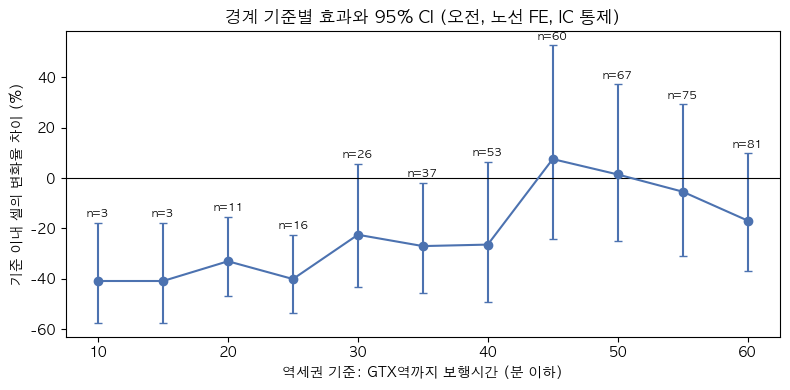

In [10]:
# 단일 경계 곡선: 기준 이내 = 1, + IC + 노선 FE
curve = []
for cutoff in range(10, 65, 5):
    f = morning.assign(near=(morning.walk_min <= cutoff).astype(float))
    if f.near.sum() == 0:
        continue
    r = fit(f, ["near", "ic_access"])
    lo, hi = r.conf_int().loc["near"]
    curve.append({"기준(분)": cutoff, "기준 이내 셀": f.loc[f.near == 1, "셀 ID"].nunique(), "효과(%)": ic1km(r.params["near"]),
                  "CI 하한": ic1km(lo), "CI 상한": ic1km(hi), "p": r.pvalues["near"]})
curve = pd.DataFrame(curve)
display(curve.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(curve["기준(분)"], curve["효과(%)"], yerr=[curve["효과(%)"] - curve["CI 하한"], curve["CI 상한"] - curve["효과(%)"]],
            fmt="o-", capsize=3, color="#4C72B0")
ax.axhline(0, color="black", linewidth=0.8)
for _, r in curve.iterrows():
    ax.annotate(f"n={int(r['기준 이내 셀'])}", (r["기준(분)"], r["CI 상한"]), textcoords="offset points", xytext=(0, 4), ha="center", fontsize=8)
ax.set_xlabel("역세권 기준: GTX역까지 보행시간 (분 이하)")
ax.set_ylabel("기준 이내 셀의 변화율 차이 (%)")
ax.set_title("경계 기준별 효과와 95% CI (오전, 노선 FE, IC 통제)")
plt.tight_layout()
plt.show()

**해석**
- 선형(10분당 +5.4%, p=0.025)과 구간 더미(20분 이내 −44.4%, p=0.001)에서도 같은 결론이다.
- **경계 곡선**: 기준이 10~25분일 때 기준 이내 셀의 효과가 −33~−41%로 유의하다. 30분 이상에서는 효과가 작아지고 유의성이 들쑥날쑥해진다(35분만 유의, 45분 이상은 0 근처).
- → 효과는 **보행 약 25분 이내**에 집중된다. 연속형 log 모형의 '가까울수록 급격히 커지는' 형태와 맞는다. 특정 경계를 고른 결과가 아니라는 근거로 부록 그림에 쓴다.

## 7. 추정법 · 가중치

In [11]:
X = sm.add_constant(design(morning, X_V2))
groups = pd.factorize(morning["셀 ID"])[0]
rate = morning.y2025 / morning.y2024
nb_fit = sm.NegativeBinomial(morning.y2025, X, offset=np.log(morning.y2024)).fit(disp=0, maxiter=1000, cov_type="cluster", cov_kwds={"groups": groups})
wls = sm.WLS(rate, X, weights=morning.y2024).fit(cov_type="cluster", cov_kwds={"groups": groups})
ols = sm.OLS(rate, X).fit(cov_type="cluster", cov_kwds={"groups": groups})
rows = [
    {**summary(nb_fit, "추정법: 음이항 offset (α 추정)"), "비고": f"α = {nb_fit.params['alpha']:.2f}"},
    {"검증": "추정법: WLS 변화율 (가중치 2024 승차)", "보행시간 2배당(%)": np.nan, "보행 p": wls.pvalues["log_walk"],
     "IC 1km당(%)": np.nan, "IC p": wls.pvalues["ic_access"],
     "비고": f"log보행 1단위당 {wls.params['log_walk']*100:+.1f}%p, IC 1km당 {wls.params['ic_access']*100:+.1f}%p"},
    {"검증": "추정법: OLS 변화율 (가중치 없음)", "보행시간 2배당(%)": np.nan, "보행 p": ols.pvalues["log_walk"],
     "IC 1km당(%)": np.nan, "IC p": ols.pvalues["ic_access"],
     "비고": f"log보행 1단위당 {ols.params['log_walk']*100:+.1f}%p, IC 1km당 {ols.params['ic_access']*100:+.1f}%p"},
]
for label, sub in [("2024 ≥ 20명 쌍", morning[morning.y2024 >= 20]), ("2024 < 20명 쌍", morning[morning.y2024 < 20])]:
    rows.append({**summary(fit(sub), f"규모별: {label}"), "비고": f"{len(sub)}쌍, 2024 승차의 {sub.y2024.sum()/morning.y2024.sum()*100:.0f}%"})
ROWS += rows
pd.DataFrame(rows).round(4)

,검증,보행시간 2배당(%),보행 p,IC 1km당(%),IC p,비고
0,추정법: 음이항 offset (α 추정),5.1848,0.5621,-10.0382,0.0019,α = 0.29
1,추정법: WLS 변화율 (가중치 2024 승차),NaN,0.0004,NaN,0.0017,"log보행 1단위당 +30.4%p, IC 1km당 -9.9%p"
2,추정법: OLS 변화율 (가중치 없음),NaN,0.7745,NaN,0.0492,"log보행 1단위당 +4.1%p, IC 1km당 -7.6%p"
3,규모별: 2024 ≥ 20명 쌍,32.2922,0.0002,-10.9602,0.0738,"87쌍, 2024 승차의 86%"
4,규모별: 2024 < 20명 쌍,-35.1597,0.0066,-2.2430,0.6330,"99쌍, 2024 승차의 14%"


**해석 (가장 주의할 부분)**
- **음이항(+5.2%, p=0.56)과 가중치 없는 OLS(p=0.77)에서는 보행시간 효과가 유의하지 않다.**
  - 승차인원으로 가중하는 Poisson과 WLS에서만 유의하다.
- 승차 규모별로 나누면 이유가 보인다.
  - 2024년 20명 이상 쌍(승차의 86%): **+32.3%, p<0.001**
  - 20명 미만 쌍(14%): **반대 방향 −35.2%, p=0.007**
- 즉 **효과는 승차가 많은 정류장에서 나타나고**, 승차 몇 명짜리 쌍에서는 반대이거나 잡음이다. 하루치 데이터에서 1~19명짜리 변화율은 매우 불안정하다(예: 1명 → 4명이면 +300%).
- → 이 연구의 추정 대상은 **"승객 수 기준 변화율"**이고, 결론은 **승객 대부분이 이용하는 주요 정류장에 대한 것**이다. 논문에 이렇게 명시하고, 규모별 결과를 부록에 넣는다. "모든 정류장에서 평균적으로"라고 쓰면 안 된다.
- IC 효과는 음이항, WLS, OLS에서 모두 유의하다. 가중치에 덜 민감하다.

## 8. offset 가정 (13번 재확인)

In [12]:
other = (trips[~trips["시"].between(*MORNING_HOURS)]
         .pivot_table(index=["셀 ID", "노선"], columns="연도", values="승차인원", aggfunc="sum", fill_value=0)
         .reset_index().rename(columns={2024: "other2024"}))
other["셀 ID"] = other["셀 ID"].astype(int)
mo = morning.merge(other[["셀 ID", "노선", "other2024"]], on=["셀 ID", "노선"], how="left").fillna({"other2024": 0})
mo["log_y2024"], mo["log_other2024"] = np.log(mo.y2024), np.log1p(mo.other2024)
free = fit(mo, X_V2 + ["log_y2024"], offset=False)
indep = fit(mo, X_V2 + ["log_other2024"])
rows = [{**summary(free, "offset: θ 자유 추정"), "비고": f"θ = {free.params['log_y2024']:.3f} (H0 θ=1 p = {2*norm.sf(abs((free.params['log_y2024']-1)/free.bse['log_y2024'])):.3f})"},
        {**summary(indep, "offset: θ=1 + 독립 규모 통제"), "비고": f"규모 계수 {indep.params['log_other2024']:.3f} (p={indep.pvalues['log_other2024']:.2f})"}]
ROWS += rows
pd.DataFrame(rows).round(4)

,검증,보행시간 2배당(%),보행 p,IC 1km당(%),IC p,비고
0,offset: θ 자유 추정,17.2422,0.0134,-10.0444,0.0020,θ = 0.852 (H0 θ=1 p = 0.039)
1,offset: θ=1 + 독립 규모 통제,28.1108,0.0000,-11.6413,0.0008,규모 계수 0.016 (p=0.81)


**해석**
- θ = 0.85로 1과 다르다(p=0.039). 하지만 θ를 자유롭게 둬도 보행시간 +17.2%(p=0.013), IC −10.0%(p=0.002)로 유지된다.
- 독립 규모 통제(2024년 오전 외 승차)의 계수는 0이고(0.016, p=0.81), 결과도 그대로다.
- → θ<1은 하루치 기준값의 잡음 때문이다. θ 자유 결과를 보행시간 효과의 **보수적 하한(+17%)**으로 같이 보고한다.

---
## 종합표

모든 검증을 한 표에 모았다. 보행시간 효과가 + 이면 '역에서 멀수록 덜 감소' = **역에 가까울수록 더 감소**(가설 방향). IC 효과가 − 이면 'IC에서 멀수록 더 감소'.

In [13]:
table = pd.DataFrame(ROWS)
# 방향까지 본다: 보행시간 효과는 +, IC 효과는 −가 가설 방향 (값이 없는 행은 비고의 계수 방향이 가설과 같음)
walk_opposite = table["보행시간 2배당(%)"] < 0
ic_opposite = table["IC 1km당(%)"] > 0
table["보행 판정"] = np.select([(table["보행 p"] < 0.05) & walk_opposite, table["보행 p"] < 0.05, table["보행 p"] < 0.1],
                              ["반대 방향 유의", "유의", "경계"], "n.s.")
table["IC 판정"] = np.select([(table["IC p"] < 0.05) & ic_opposite, table["IC p"] < 0.05, table["IC p"] < 0.1],
                            ["반대 방향 유의", "유의", "경계"], "n.s.")
cols = ["검증", "보행시간 2배당(%)", "보행 p", "보행 판정", "IC 1km당(%)", "IC p", "IC 판정", "비고"]
table = table.reindex(columns=cols)
pd.set_option("display.max_colwidth", 80)
for label, column in [("보행시간", "보행 판정"), ("IC", "IC 판정")]:
    counts = table[column].iloc[1:].value_counts().to_dict()
    print(f"{label}: 검증 {len(table) - 1}개 중 {counts}")
table.round(4)

보행시간: 검증 29개 중 {'유의': 22, 'n.s.': 6, '반대 방향 유의': 1}
IC: 검증 29개 중 {'유의': 24, 'n.s.': 4, '경계': 1}


,검증,보행시간 2배당(%),보행 p,보행 판정,IC 1km당(%),IC p,IC 판정,비고
0,★ v2 본모형,27.1165,0.0000,유의,-11.6237,0.0007,유의,NaN
1,역 권역 제외: 운정중앙,34.9881,0.0003,유의,-11.0967,0.0393,유의,NaN
2,역 권역 제외: 킨텍스,11.7053,0.1221,n.s.,-11.8941,0.0010,유의,NaN
3,역 권역 제외: 대곡,20.8753,0.0002,유의,-7.6623,0.0340,유의,NaN
4,셀 하나씩 빼기 (118회) — 보행 p가 가장 큰 경우 (셀 ID 12765.0),27.0233,0.0041,유의,-11.6164,0.0014,유의,NaN
5,셀 하나씩 빼기 (118회) — IC p가 가장 큰 경우 (셀 ID 12464.0),24.6641,0.0002,유의,-10.3257,0.0028,유의,NaN
6,노선 하나씩 빼기 (24회) — 보행 p가 가장 큰 경우 (노선 M7731),25.2164,0.0105,유의,-11.9903,0.0012,유의,NaN
7,노선 하나씩 빼기 (24회) — IC p가 가장 큰 경우 (노선 3100),25.1761,0.0002,유의,-10.8186,0.0030,유의,NaN
8,고정효과: FE 없음,11.4633,0.1024,n.s.,-10.0197,0.0034,유의,NaN
9,고정효과: 역 FE,5.8890,0.3019,n.s.,-5.9288,0.0491,유의,NaN


## 최종 판단

| 검증 | 보행시간 (log) | IC 도로거리 |
|---|---|---|
| 셀·노선 하나씩 빼기 | ✅ 모두 유의 | ✅ 모두 유의 |
| 역 권역 빼기 | ⚠️ **킨텍스 빼면 n.s.** | ✅ |
| 고정효과 | ⚠️ 노선 FE 필요 (FE 없음·역 FE만이면 n.s.), **노선+역 FE는 유의** | ✅ |
| 공간 (Moran, 읍면동, Conley) | ✅ | ✅ |
| 0 포함 패널 | ✅ | ✅ |
| 시간대 | ✅ (저녁만 n.s.) | ⚠️ 출근 시간대에서만 유의 |
| 함수형·경계 | ✅ 효과는 약 25분 이내에 집중 | ✅ |
| 추정법·가중치 | ⚠️ **승객 가중일 때만 유의** (음이항·OLS n.s., 소규모 쌍은 반대) | ✅ |
| offset 가정 | ✅ θ 자유에서도 유의 (+17%) | ✅ |

**결론**
- **IC 도로거리 효과는 매우 견고하다.** 출근 시간대 한정이라는 조건만 붙이면 된다.
- **보행시간 효과는 조건부로 견고하다.** "같은 노선 안에서, 승차가 많은 주요 정류장에서, 출근·주간 시간대에" 역에 가까울수록 더 줄었다. 이 세 조건이 결과의 범위이고, 논문에 그대로 밝혀야 한다.
- 가장 큰 약점은 두 가지다. ① **킨텍스 권역 의존**, ② **승객 가중 의존**. 둘 다 하루치 데이터와 20분 이내 셀이 적은 문제에서 나온다. 데이터 기간을 늘리면 가장 먼저 다시 확인할 부분이다.

**논문 서술 권장 문장**
> "노선 고정효과를 포함한 Poisson 변화율 모형에서 GTX-A역까지 보행시간이 2배 짧을수록 출근 시간대 광역버스 승차 변화율은 약 21% 낮았다(보행시간 2배당 +27.1%, 95% CI 13.9~41.9%). 이 효과는 노선·역 권역 고정효과를 함께 통제해도 유지되었다(+19.4%). 다만 효과는 승차 규모가 큰 정류장에서 주로 나타났으며(2024년 20명 이상 셀×노선: +32.3%), 킨텍스역 권역을 제외하면 유의하지 않았다(p=0.12)."